In [1]:
import os
import sys
import json
import time
import joblib
import numpy as np
import pandas as pd
import pprint as pp
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from pathlib import Path
from typing import List

import umap
import umap.plot

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
from torch import optim
from sklearn.model_selection import train_test_split

# 현재 노트북이 있는 경로 기준으로 프로젝트 루트(recsys) 경로 계산
current_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# recsys 폴더를 sys.path에 추가
if project_root not in sys.path:
    sys.path.append(project_root)

from setup_env import setup_env

root_dir = setup_env()

from utils.dataset.config import DatasetPath
from utils.serving.artifact import register_artifact_model
from models.transformer.transformer import SimpleTransformer
from models.transformer.preprocess import (
    FeatureLabelEncoder,
    SequenceGenerator,
    SequentialDataset,
    SequenceVectorDataset,
)
from models.transformer.regressor import MultiOutputRegressor

device = "cpu"

/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than

[INFO] Font applied: NanumGothic


# Load Dataset

In [2]:
# 데이터셋 경로
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(root_dir=dataset_dir, dataset_name="fashion")

df_user_logs = pd.read_parquet(paths.user_logs_path)

# `YYYY-MM-DD HH:MM:SS` -> `YYYY-MM-DD`
df_user_logs["date"] = pd.to_datetime(
    df_user_logs["timestamp"].apply(lambda x: x[:10]), format="%Y-%m-%d"
)

df_user_logs.head()

,user_id,item_id,timestamp,action,age,gender,name,brand_name,price,discount_price,...,season,year,usage,master_category,sub_category,article_type,fit,occasion,description,date
0,1,2676,2025-10-21 03:01:00,click,46,Women,Baggit Women Fighter Mayur Black Belt,Baggit,525.0,525.0,...,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p>A belt is an essential detail to complete y...,2025-10-21
1,1,2619,2025-10-21 03:02:00,click,46,Women,Baggit Women Blue Spirit Dum Belt,Baggit,575.0,575.0,...,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p><strong>Style Note </strong><br />A summer ...,2025-10-21
2,1,1617,2025-10-21 03:05:00,click,46,Women,Baggit Women Flora Moly Red Belt,Baggit,500.0,500.0,...,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p><strong>Style Note</strong><br /> A belt is...,2025-10-21
3,1,8224,2025-10-21 03:04:00,click,46,Women,Baggit Women Brown Xylo Taj Belt,Baggit,575.0,575.0,...,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,<p><strong>Style Note </strong><br />A summer ...,2025-10-21
4,1,1114,2025-10-21 03:17:00,click,46,Women,Wills Lifestyle Women Leather Blue Belt,Wills Lifestyle,999.0,649.0,...,Summer,2012,Casual,Accessories,Belts,Belts,<UNK>,<UNK>,"<div><span style=""font-family: tahoma, arial, ...",2025-10-21


# User Behavior Sequence
- 입력 길이를 결정하기 위한 아이템 시퀀스 분포 확인

In [3]:
# 일별, 유저별 평균 탐색 아이템 수 집계
df_agg = (
    df_user_logs.groupby(["date", "user_id"])["item_id"]
    .agg(n_items="nunique")
    .reset_index()
)
df_agg = df_agg.groupby("date")["n_items"].mean().reset_index()
df_agg = df_agg[df_agg["date"] < "2025-11-01"].reset_index(drop=True)

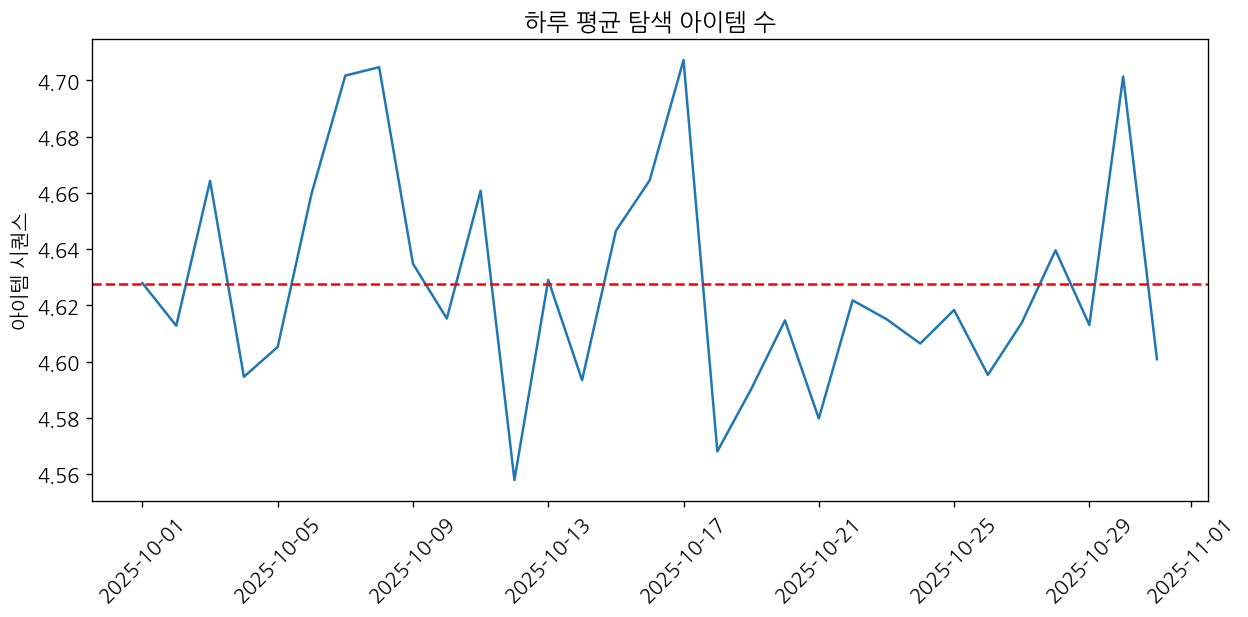

In [4]:
# 날짜별 탐색 아이템 수 확인
plt.figure(figsize=(12, 5), dpi=120)
sns.lineplot(data=df_agg, x="date", y="n_items")
plt.xlabel("")
plt.ylabel("아이템 시퀀스")
plt.xticks(rotation=45)
plt.axhline(y=df_agg["n_items"].mean(), color="r", linestyle="--")
plt.title("하루 평균 탐색 아이템 수")
plt.show()

In [5]:
max_seq_len = 5

# Preprocess

In [6]:
# 모델 저장 경로 생성 (전처리 및 학습 관련 결과물)
model_dir = Path(root_dir).joinpath("data/outputs/fashion/transformer")
model_dir.mkdir(parents=True, exist_ok=True)

## Label Encoding

In [7]:
# 인코딩 대상 feature 정의
feature_names = [
    "brand_name",
    "gender",
    "age_group",
    "base_color",
    "season",
    "year",
    "usage",
    "master_category",
    "sub_category",
    "article_type",
    "fit",
    "occasion",
    "action",  # 사용자 행동 (click, purchase 등)
]
df_prep = df_user_logs[feature_names]

# FeatureLabelEncoder 초기화
label_encoders = FeatureLabelEncoder()

# LabelEncoder 학습 & 변환
label_encoders.fit(df_prep)

# 정수 인코딩 적용
df_encoded = label_encoders.transform(df_prep)

# item_id, user_id, timestamp 복원
for i, column in enumerate(["user_id", "item_id", "timestamp"]):
    df_encoded.insert(i, column, df_user_logs[column])

# 유저별 행동 로그가 2개 이상인 경우만 유지
df_encoded = df_encoded.groupby("user_id").filter(lambda x: len(x) > 1)


df_encoded = df_encoded.sort_values(["user_id", "timestamp"], ignore_index=True)
df_encoded.head()

,user_id,item_id,timestamp,brand_name,gender,age_group,base_color,season,year,usage,master_category,sub_category,article_type,fit,occasion,action
0,1,4951,2025-10-06 17:46:00,60,6,4,13,3,2,2,4,29,33,1,2,3
1,1,8952,2025-10-06 17:47:00,272,6,4,21,3,2,2,4,29,33,1,1,3
2,1,8113,2025-10-06 17:48:00,60,6,4,6,3,2,2,4,29,33,1,2,5
3,1,3887,2025-10-06 17:58:00,60,6,4,40,3,2,2,4,29,33,1,2,3
4,1,3887,2025-10-08 09:05:00,60,6,4,40,3,2,2,4,29,33,1,2,3


In [8]:
# unseen label 토큰("<UNK>")이 올바르게 인코딩 되었는지 확인
for x in feature_names:
    # "<UNK>"가 실제로 어떤 정수로 인코딩 되었는지 확인
    x_encoded = label_encoders._all_encoders[x].transform(["<UNK>"])
    # 해당 인코딩된 값이 제대로 복원되는지 확인
    x_decoded = label_encoders._all_encoders[x].inverse_transform(x_encoded)
    print(f"{x}: {x_encoded} -> {x_decoded}")

brand_name: [5] -> ['<UNK>']
gender: [1] -> ['<UNK>']
age_group: [1] -> ['<UNK>']
base_color: [1] -> ['<UNK>']
season: [1] -> ['<UNK>']
year: [9] -> ['<UNK>']
usage: [1] -> ['<UNK>']
master_category: [1] -> ['<UNK>']
sub_category: [1] -> ['<UNK>']
article_type: [1] -> ['<UNK>']
fit: [1] -> ['<UNK>']
occasion: [1] -> ['<UNK>']
action: [1] -> ['<UNK>']


In [9]:
# 특수 토큰("-1")이 올바르게 인코딩 되었는지 검증
for x in feature_names:
    # "-1"이 실제로 어떤 정수로 인코딩 되었는지 확인
    x_encoded = label_encoders._all_encoders[x].transform(["-1"])
    # 정수 0이 다시 "-1"로 복원되는지 확인
    x_decoded = label_encoders._all_encoders[x].inverse_transform([0])
    print(f"{x}: {x_encoded} -> {x_decoded}")

brand_name: [0] -> ['-1']
gender: [0] -> ['-1']
age_group: [0] -> ['-1']
base_color: [0] -> ['-1']
season: [0] -> ['-1']
year: [0] -> ['-1']
usage: [0] -> ['-1']
master_category: [0] -> ['-1']
sub_category: [0] -> ['-1']
article_type: [0] -> ['-1']
fit: [0] -> ['-1']
occasion: [0] -> ['-1']
action: [0] -> ['-1']


In [10]:
# Label Encoder 저장 경로 생성
model_dir.joinpath("label_encoders/").mkdir(parents=True, exist_ok=True)

# feature별 인코더 저장
for feature, encoder in label_encoders.all_encoders.items():
    file_name = f"{feature}.joblib"
    file_path = model_dir.joinpath(f"label_encoders/{file_name}")
    joblib.dump(encoder, file_path)

## Sequence Generation

In [11]:
# 타겟으로 사용할 feature 지정 (여기서는 feature_names 전체를 타겟 후보로 사용)
# 단, 'action'은 target에서 제외
target_names = [x for x in feature_names if x != "action"]

# 시퀀스 데이터셋 생성기 초기화 (`max_seq_len` 길이의 시퀀스를 만들도록 설정)
sequence_generator = SequenceGenerator(max_seq_len=max_seq_len)

# 시퀀스 데이터셋 변환
df_seq_encoded = sequence_generator.get_seq_dataframe(
    data=df_encoded,  # 인코딩된 원본 데이터
    feature_sequences=feature_names,  # 시퀀스로 만들 feature 컬럼들
    output_targets=target_names,  # 다음 스텝 예측할 타겟 컬럼들
)
df_seq_encoded["y_item_id"] = df_seq_encoded["y_item_id"].astype(int)

# Null 값이 포함된 행 제거
# - `shift(-1)` 연산 때문에 마지막 이벤트는 target이 없음(NULL 발생)
# - 따라서 학습 가능한 행만 추출
df_seq_encoded = df_seq_encoded[df_seq_encoded.notna().all(axis=1)].reset_index(
    drop=True
)

print(df_seq_encoded.shape)

(208501, 30)


In [12]:
df_seq_encoded

,user_id,user_rn,seq_len,mask,brand_name,gender,age_group,base_color,season,year,...,t_base_color,t_season,t_year,t_usage,t_master_category,t_sub_category,t_article_type,t_fit,t_occasion,y_item_id
0,1,1,1,"[0, 1, 1, 1, 1]","[60, 0, 0, 0, 0]","[6, 0, 0, 0, 0]","[4, 0, 0, 0, 0]","[13, 0, 0, 0, 0]","[3, 0, 0, 0, 0]","[2, 0, 0, 0, 0]",...,"[21, 0, 0, 0, 0]","[3, 0, 0, 0, 0]","[2, 0, 0, 0, 0]","[2, 0, 0, 0, 0]","[4, 0, 0, 0, 0]","[29, 0, 0, 0, 0]","[33, 0, 0, 0, 0]","[1, 0, 0, 0, 0]","[1, 0, 0, 0, 0]",8952
1,1,2,2,"[0, 0, 1, 1, 1]","[60, 272, 0, 0, 0]","[6, 6, 0, 0, 0]","[4, 4, 0, 0, 0]","[13, 21, 0, 0, 0]","[3, 3, 0, 0, 0]","[2, 2, 0, 0, 0]",...,"[21, 6, 0, 0, 0]","[3, 3, 0, 0, 0]","[2, 2, 0, 0, 0]","[2, 2, 0, 0, 0]","[4, 4, 0, 0, 0]","[29, 29, 0, 0, 0]","[33, 33, 0, 0, 0]","[1, 1, 0, 0, 0]","[1, 2, 0, 0, 0]",8113
2,1,3,3,"[0, 0, 0, 1, 1]","[60, 272, 60, 0, 0]","[6, 6, 6, 0, 0]","[4, 4, 4, 0, 0]","[13, 21, 6, 0, 0]","[3, 3, 3, 0, 0]","[2, 2, 2, 0, 0]",...,"[21, 6, 40, 0, 0]","[3, 3, 3, 0, 0]","[2, 2, 2, 0, 0]","[2, 2, 2, 0, 0]","[4, 4, 4, 0, 0]","[29, 29, 29, 0, 0]","[33, 33, 33, 0, 0]","[1, 1, 1, 0, 0]","[1, 2, 2, 0, 0]",3887
3,1,4,4,"[0, 0, 0, 0, 1]","[60, 272, 60, 60, 0]","[6, 6, 6, 6, 0]","[4, 4, 4, 4, 0]","[13, 21, 6, 40, 0]","[3, 3, 3, 3, 0]","[2, 2, 2, 2, 0]",...,"[21, 6, 40, 40, 0]","[3, 3, 3, 3, 0]","[2, 2, 2, 2, 0]","[2, 2, 2, 2, 0]","[4, 4, 4, 4, 0]","[29, 29, 29, 29, 0]","[33, 33, 33, 33, 0]","[1, 1, 1, 1, 0]","[1, 2, 2, 2, 0]",3887
4,1,5,5,"[0, 0, 0, 0, 0]","[60, 272, 60, 60, 60]","[6, 6, 6, 6, 6]","[4, 4, 4, 4, 4]","[13, 21, 6, 40, 40]","[3, 3, 3, 3, 3]","[2, 2, 2, 2, 2]",...,"[21, 6, 40, 40, 13]","[3, 3, 3, 3, 3]","[2, 2, 2, 2, 2]","[2, 2, 2, 2, 2]","[4, 4, 4, 4, 4]","[29, 29, 29, 29, 29]","[33, 33, 33, 33, 33]","[1, 1, 1, 1, 1]","[1, 2, 2, 2, 2]",4951
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208496,10000,18,5,"[0, 0, 0, 0, 0]","[245, 6, 255, 216, 222]","[6, 4, 4, 4, 4]","[4, 2, 2, 2, 2]","[24, 47, 3, 35, 47]","[4, 4, 4, 4, 4]","[1, 1, 1, 1, 1]",...,"[47, 3, 35, 47, 15]","[4, 4, 4, 4, 4]","[1, 1, 1, 1, 1]","[2, 2, 2, 2, 2]","[3, 3, 3, 3, 3]","[35, 35, 35, 35, 35]","[115, 115, 115, 115, 115]","[5, 3, 3, 3, 3]","[1, 2, 1, 1, 1]",6069
208497,10000,19,5,"[0, 0, 0, 0, 0]","[6, 255, 216, 222, 179]","[4, 4, 4, 4, 4]","[2, 2, 2, 2, 2]","[47, 3, 35, 47, 15]","[4, 4, 4, 4, 4]","[1, 1, 1, 1, 1]",...,"[3, 35, 47, 15, 15]","[4, 4, 4, 4, 4]","[1, 1, 1, 1, 1]","[2, 2, 2, 2, 2]","[3, 3, 3, 3, 3]","[35, 35, 35, 35, 35]","[115, 115, 115, 115, 115]","[3, 3, 3, 3, 3]","[2, 1, 1, 1, 2]",741
208498,10000,20,5,"[0, 0, 0, 0, 0]","[255, 216, 222, 179, 216]","[4, 4, 4, 4, 4]","[2, 2, 2, 2, 2]","[3, 35, 47, 15, 15]","[4, 4, 4, 4, 4]","[1, 1, 1, 1, 1]",...,"[35, 47, 15, 15, 4]","[4, 4, 4, 4, 4]","[1, 1, 1, 1, 4]","[2, 2, 2, 2, 2]","[3, 3, 3, 3, 3]","[35, 35, 35, 35, 35]","[115, 115, 115, 115, 115]","[3, 3, 3, 3, 3]","[1, 1, 1, 2, 2]",6724
208499,10000,21,5,"[0, 0, 0, 0, 0]","[216, 222, 179, 216, 20]","[4, 4, 4, 4, 6]","[2, 2, 2, 2, 4]","[35, 47, 15, 15, 4]","[4, 4, 4, 4, 4]","[1, 1, 1, 1, 4]",...,"[47, 15, 15, 4, 34]","[4, 4, 4, 4, 4]","[1, 1, 1, 4, 1]","[2, 2, 2, 2, 2]","[3, 3, 3, 3, 3]","[35, 35, 35, 35, 35]","[115, 115, 115, 115, 115]","[3, 3, 3, 3, 3]","[1, 1, 2, 2, 1]",7291


# Model

## Dataset

In [13]:
# Train / Test 데이터 분리
df_train, df_test = train_test_split(
    df_seq_encoded,  # 전체 시퀀스 데이터셋
    test_size=0.2,  # 20%는 검증용
    random_state=42,
    shuffle=True,  # 학습 시 mini-batch 샘플링을 무작위로 하여 일반화 성능 향상
)
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Train Dataset 객체 생성
train_dataset = SequentialDataset(
    df=df_train,
    feature_sequences=feature_names + ["mask"],  # 입력 feature 시퀀스 + 패딩 마스크
    action_sequence="action",  # 행동 시퀀스
    targets=target_names,  # 예측할 타겟 label
)

# DataLoader 설정
# - `batch_size`: 메모리에 따라 조정 가능
# - `shuffle=True`: 학습 시 mini-batch 샘플링을 무작위로 하여 일반화 성능 향상
# - `pin_memory=False`: DataLoader에서 메모리 고정 기능 (GPU transfer 최적화)
batch_size = 64
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,  # 미니배치 크기
    shuffle=True,  # 학습 시 mini-batch 샘플링을 무작위로 하여 일반화 성능 향상
    pin_memory=False,  # DataLoader에서 메모리 고정 기능 (GPU transfer 최적화)
)

## Model Config

In [14]:
def set_model_config(
    df: pd.DataFrame,
    feature_names: List[str],
    target_names: List[str],
    label_encoders: FeatureLabelEncoder,
    seq_len: int,
) -> dict:
    """
    Transformer 모델 설정(config) 생성

    :param df: 인코딩된 데이터프레임
    :param feature_names: 입력 feature 컬럼명
    :param target_names: target label 컬럼명
    :param label_encoders: FeatureLabelEncoder 객체
    :param seq_len: 시퀀스 최대 길이
    :return: config 딕셔너리
    """

    # -----------------------------------------------
    # 1) feature_dims 생성
    # -----------------------------------------------
    feature_dims = {
        feat: len(label_encoders.all_encoders[feat].classes_) for feat in feature_names
    }

    # 행동별 가중치를 적용한다면 가중치를 미리 정의
    if "action" in feature_dims:
        action_weights = {"click": 1, "wishlist": 2, "cart": 3, "purchase": 4}
        action_idx_weights = {}
        for action, weight in action_weights.items():
            action_idx = (
                label_encoders.all_encoders["action"].transform([action]).item()
            )
            action_idx_weights[int(action_idx)] = weight
    else:
        action_idx_weights = None

    # 임베딩 차원 크기 (고정값)
    embedding_dim = 64

    # -----------------------------------------------
    # 2) output_dims 생성
    # -----------------------------------------------
    output_dims = {}
    for target in target_names:
        #  target label별 클래스 개수
        max_id = max(max(seq) for seq in df[target].tolist())
        output_dims[target] = int(max_id) + 1

    # -----------------------------------------------
    # 3) 최종 config dict 반환
    # -----------------------------------------------
    return dict(
        seq_len=seq_len,  # 입력 시퀀스 길이
        feature_dims=feature_dims,  # feature별 클래스 개수
        action_weights=action_idx_weights,  # 행동 가중치
        embedding_dim=embedding_dim,  # 임베딩 차원
        output_dims=output_dims,  # task별 클래스 개수
        global_pool="sum",  # pooling 방식 (sum pooling)
    )


# Config 생성 및 저장
print("------------------ Model Config ------------------")
model_config = set_model_config(
    df=df_seq_encoded,
    label_encoders=label_encoders,
    feature_names=feature_names,
    target_names=target_names,
    seq_len=max_seq_len,
)
pp.pprint(model_config)

# 체크포인트 디렉토리 생성
checkpoint = model_dir.joinpath("checkpoint")
checkpoint.mkdir(parents=True, exist_ok=True)

# 모델 설정을 JSON 파일로 저장 (추후 재현/재학습 가능)
with open(checkpoint.joinpath("model_config.json"), "w") as f:
    json.dump(model_config, f, ensure_ascii=False, indent=4)

------------------ Model Config ------------------
{'action_weights': {2: 3, 3: 1, 4: 4, 5: 2},
 'embedding_dim': 64,
 'feature_dims': {'action': 6,
                  'age_group': 8,
                  'article_type': 122,
                  'base_color': 49,
                  'brand_name': 354,
                  'fit': 9,
                  'gender': 7,
                  'master_category': 7,
                  'occasion': 15,
                  'season': 6,
                  'sub_category': 39,
                  'usage': 10,
                  'year': 10},
 'global_pool': 'sum',
 'output_dims': {'age_group': 8,
                 'article_type': 122,
                 'base_color': 49,
                 'brand_name': 354,
                 'fit': 9,
                 'gender': 7,
                 'master_category': 7,
                 'occasion': 15,
                 'season': 6,
                 'sub_category': 39,
                 'usage': 10,
                 'year': 9},
 'seq_len': 5}


## Training

In [15]:
# 자동 미분 중 이상 발생 시, 디버깅 정보를 표시 (학습 과정 디버깅용)
torch.autograd.set_detect_anomaly(True)

# -----------------------------------------------
# 1) 모델 선언
# -----------------------------------------------
model = SimpleTransformer(**model_config)

# -----------------------------------------------
# 2) Loss 함수 정의
# -----------------------------------------------
# target별 CrossEntropyLoss 사용
# `ignore_index=0`: 패딩 토큰(0)은 Loss 계산에서 제외
loss_funcs = {
    target: nn.CrossEntropyLoss(ignore_index=0).to(device) for target in target_names
}

# -----------------------------------------------
# 3) 옵티마이저 정의
# -----------------------------------------------
# AdamW (Adam + weight decay) 사용 -> Transformer 학습에 안정적
optimizer = optim.AdamW(model.parameters(), weight_decay=0.01, lr=0.001)

# -----------------------------------------------
# 4) 학습 준비
# -----------------------------------------------
df_metrics = pd.DataFrame()  # 학습 로그 저장용
n_epochs = 10
model = model.to(device)

# -----------------------------------------------
# 5) Epoch 반복
# -----------------------------------------------
for epoch in range(n_epochs):
    train_start_time = time.time()
    model.train()  # 학습 모드 전환 (dropout 등 활성화)

    # -----------------------------------------------
    # Epoch 내 손실(loss)과 정확도(accuracy) 기록용 변수 초기화
    # -----------------------------------------------
    # target별 손실값 누적용 딕셔너리 (예: {"y_color": 0, "y_category": 0, ...})
    running_loss = {target: 0 for target in target_names}

    # target별 정확도 기록용 딕셔너리
    # - "token": 배치별 token-level accuracy 리스트
    # - "sequence": 배치별 sequence-level accuracy 리스트
    # (epoch 종료 후 평균을 계산하기 위해 리스트로 기록)
    # 예: {"y_color": {"token": [0.85, 0.87, ...], "sequence": [0.40, 0.42, ...]}, ...}
    accuracy = {target: {"token": [], "sequence": []} for target in target_names}
    running_loss = {target: 0 for target in target_names}

    # -----------------------------------------------
    # 6) 미니배치 학습
    # -----------------------------------------------
    for _, (feature_sequences, action_sequence, masks, targets) in enumerate(
        tqdm(train_dataloader, total=len(train_dataloader))
    ):
        # Gradient 초기화
        optimizer.zero_grad()

        # 모델 Forward
        outputs = model(
            feature_sequences=feature_sequences,
            action_sequence=action_sequence,
            masks=masks,
        )[1]

        # target별 Loss 계산
        losses = {target: 0 for target in target_names}
        for target, dim in model_config["output_dims"].items():
            batch_size = targets[target].size()[0]

            # logits_flat: (batch_size, seq_len, n_classes) -> (batch_size * seq_len, n_classes)
            logits_flat = outputs[target].reshape(-1, dim)

            # targets_flat: (batch_size * seq_len)
            targets_flat = targets[target].reshape(-1).long()

            # CrossEntropyLoss 계산
            try:
                losses[target] = loss_funcs[target](logits_flat, targets_flat)
            except Exception as e:
                print(
                    f"[Error] ---------------------------------- {target} ----------------------------------"
                )
                print(f"[Error]  {e}")

            # -----------------------------------------------
            # 7) Token-Level Accuracy
            # -----------------------------------------------
            # pred_flat: (batch_size * seq_len)
            pred_flat = logits_flat.argmax(dim=-1)  # 예측 label

            # Token-Level Accuracy (예측 시퀀스와 Target 시퀀스 내 동일한 원소 비율)
            correct = (pred_flat == targets_flat) & (targets_flat != 0)  # 패딩 제외
            valid_token_cnt = (targets_flat != 0).sum().item()
            # division by zero 에러 방지
            if valid_token_cnt > 0:
                token_accuracy = correct.sum().item() / valid_token_cnt
            else:
                token_accuracy = 0.0

            # -----------------------------------------------
            # 8) Sequence-Level Accuracy
            # -----------------------------------------------
            # (예측 시퀀스와 Target 시퀀스가 동일한 비율)
            # pred: (batch_size, seq_len)
            pred = pred_flat.reshape(batch_size, model.seq_len)
            is_padding = masks.bool()  # True = 패딩, False = 유효
            # 모든 토큰이 정확한 시퀀스의 비율
            correct_or_padding = (pred == targets[target]) | is_padding
            sequence_correct = correct_or_padding.all(dim=1)
            # Accuracy 기록
            sequence_accuracy = sequence_correct.sum().item() / batch_size

            accuracy[target]["token"].append(token_accuracy)
            accuracy[target]["sequence"].append(sequence_accuracy)

        # -----------------------------------------------
        # 9) 역전파 & 파라미터 업데이트
        # -----------------------------------------------
        total_loss = sum(losses.values())
        total_loss.backward()
        optimizer.step()

        # 배치별 Loss 기록
        for target, loss in losses.items():
            running_loss[target] += float(loss)
        running_loss["total"] = float(total_loss)

    # -----------------------------------------------
    # 10) 체크포인트 저장
    # -----------------------------------------------
    torch.save(model.state_dict(), checkpoint.joinpath("model.pt"))

    # -----------------------------------------------
    # 11) Epoch 결과 출력
    # -----------------------------------------------
    train_end_time = time.time()
    train_time = round(train_end_time - train_start_time, 2)
    print(f"Epoch {epoch + 1}/{n_epochs} - Loss & Accuracy (Token, Sequence)")
    for target in target_names:
        loss = running_loss[target] / len(train_dataloader)
        token_accuracy = np.mean(accuracy[target]["token"])
        sequence_accuracy = np.mean(accuracy[target]["sequence"])
        print(
            f"Loss `{target}`: {loss:.4f} ({token_accuracy:.2%}, {sequence_accuracy:.2%})"
        )

        df_metrics_tmp = pd.DataFrame(
            {
                "epoch": [epoch + 1],
                "target": [target],
                "loss": [loss],
                "token_accuracy": [token_accuracy],
                "sequence_accuracy": [sequence_accuracy],
            }
        )
        df_metrics = pd.concat([df_metrics, df_metrics_tmp], ignore_index=True)
    print(f"Total Loss: {running_loss['total']:.4f}")
    print(f"Elapsed time(sec): {train_time:.2f}\n")

# -----------------------------------------------
# 12) 학습 로그 저장
# -----------------------------------------------
df_metrics.to_csv(model_dir.joinpath("metrics_train.csv"), index=False)

  0%|          | 0/2607 [00:00<?, ?it/s]

Epoch 1/10 - Loss & Accuracy (Token, Sequence)
Loss `brand_name`: 0.4178 (93.09%, 87.71%)
Loss `gender`: 0.0333 (99.58%, 99.14%)
Loss `age_group`: 0.0370 (99.55%, 99.10%)
Loss `base_color`: 0.2012 (96.24%, 91.94%)
Loss `season`: 0.0385 (99.40%, 98.68%)
Loss `year`: 0.0473 (99.25%, 97.90%)
Loss `usage`: 0.0344 (99.49%, 98.96%)
Loss `master_category`: 0.0314 (99.66%, 99.34%)
Loss `sub_category`: 0.1008 (98.50%, 97.59%)
Loss `article_type`: 0.1838 (97.24%, 95.55%)
Loss `fit`: 0.0320 (99.61%, 98.86%)
Loss `occasion`: 0.0547 (99.21%, 97.89%)
Total Loss: 0.0292
Elapsed time(sec): 294.51



  0%|          | 0/2607 [00:00<?, ?it/s]

Epoch 2/10 - Loss & Accuracy (Token, Sequence)
Loss `brand_name`: 0.0036 (99.99%, 99.98%)
Loss `gender`: 0.0006 (99.99%, 99.98%)
Loss `age_group`: 0.0006 (99.99%, 99.98%)
Loss `base_color`: 0.0020 (99.99%, 99.97%)
Loss `season`: 0.0007 (100.00%, 99.99%)
Loss `year`: 0.0007 (100.00%, 99.99%)
Loss `usage`: 0.0009 (99.99%, 99.95%)
Loss `master_category`: 0.0005 (100.00%, 99.99%)
Loss `sub_category`: 0.0012 (99.99%, 99.98%)
Loss `article_type`: 0.0023 (99.99%, 99.97%)
Loss `fit`: 0.0005 (100.00%, 99.99%)
Loss `occasion`: 0.0008 (100.00%, 99.98%)
Total Loss: 0.0031
Elapsed time(sec): 290.10



  0%|          | 0/2607 [00:00<?, ?it/s]

...

Epoch 8/10 - Loss & Accuracy (Token, Sequence)
Loss `brand_name`: 0.0004 (99.99%, 99.97%)
Loss `gender`: 0.0001 (100.00%, 99.99%)
Loss `age_group`: 0.0001 (100.00%, 99.99%)
Loss `base_color`: 0.0003 (99.99%, 99.97%)
Loss `season`: 0.0001 (100.00%, 99.99%)
Loss `year`: 0.0001 (100.00%, 99.98%)
Loss `usage`: 0.0001 (100.00%, 99.99%)
Loss `master_category`: 0.0001 (100.00%, 99.99%)
Loss `sub_category`: 0.0001 (100.00%, 99.99%)
Loss `article_type`: 0.0003 (99.99%, 99.98%)
Loss `fit`: 0.0001 (100.00%, 99.98%)
Loss `occasion`: 0.0001 (100.00%, 99.99%)
Total Loss: 0.0005
Elapsed time(sec): 290.74



  0%|          | 0/2607 [00:00<?, ?it/s]

Epoch 9/10 - Loss & Accuracy (Token, Sequence)
Loss `brand_name`: 0.0000 (100.00%, 100.00%)
Loss `gender`: 0.0000 (100.00%, 100.00%)
Loss `age_group`: 0.0000 (100.00%, 100.00%)
Loss `base_color`: 0.0000 (100.00%, 100.00%)
Loss `season`: 0.0000 (100.00%, 100.00%)
Loss `year`: 0.0000 (100.00%, 100.00%)
Loss `usage`: 0.0000 (100.00%, 100.00%)
Loss `master_category`: 0.0000 (100.00%, 100.00%)
Loss `sub_category`: 0.0000 (100.00%, 100.00%)
Loss `article_type`: 0.0000 (100.00%, 100.00%)
Loss `fit`: 0.0000 (100.00%, 100.00%)
Loss `occasion`: 0.0000 (100.00%, 100.00%)
Total Loss: 0.0000
Elapsed time(sec): 290.09



  0%|          | 0/2607 [00:00<?, ?it/s]

Epoch 10/10 - Loss & Accuracy (Token, Sequence)
Loss `brand_name`: 0.0003 (100.00%, 99.98%)
Loss `gender`: 0.0001 (100.00%, 99.99%)
Loss `age_group`: 0.0001 (100.00%, 99.99%)
Loss `base_color`: 0.0002 (100.00%, 99.99%)
Loss `season`: 0.0001 (100.00%, 99.99%)
Loss `year`: 0.0001 (100.00%, 99.99%)
Loss `usage`: 0.0004 (99.99%, 99.97%)
Loss `master_category`: 0.0001 (100.00%, 99.99%)
Loss `sub_category`: 0.0001 (100.00%, 100.00%)
Loss `article_type`: 0.0003 (99.99%, 99.98%)
Loss `fit`: 0.0002 (100.00%, 99.99%)
Loss `occasion`: 0.0001 (100.00%, 99.98%)
Total Loss: 0.0007
Elapsed time(sec): 290.76



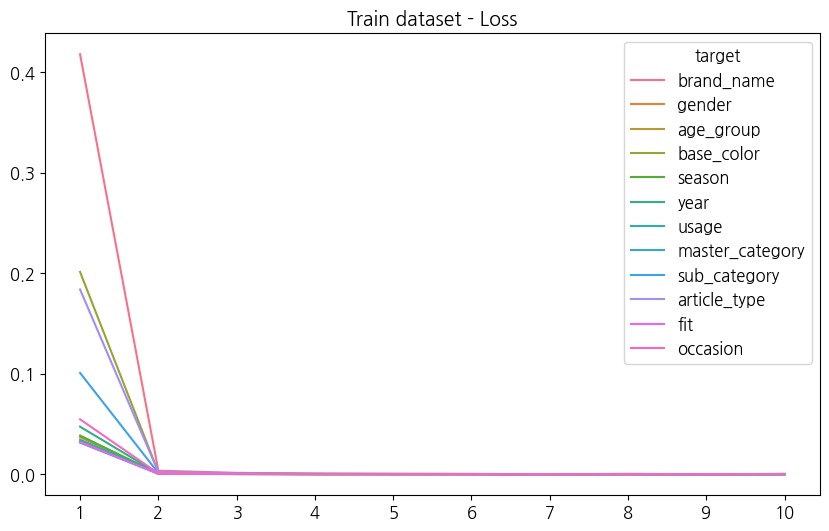

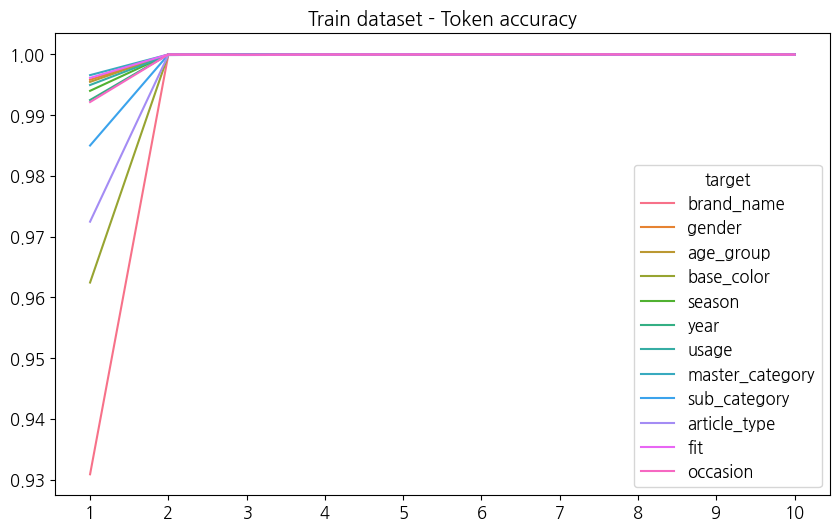

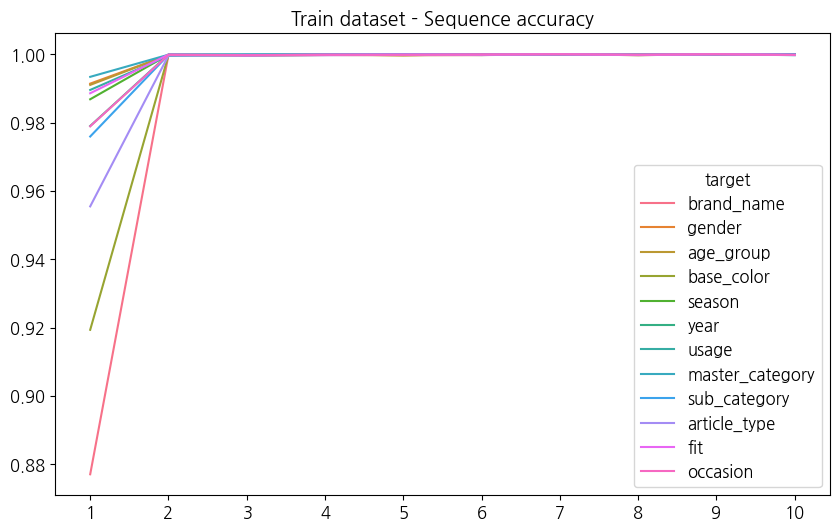

In [16]:
# 학습 로그 불러오기
df_metrics = pd.read_csv(model_dir.joinpath("metrics_train.csv"))

# 지표별 시각화
for metric in ["loss", "token_accuracy", "sequence_accuracy"]:
    plt.figure(figsize=(10, 6), dpi=100)
    sns.lineplot(x="epoch", y=metric, hue="target", data=df_metrics)
    # 그래프 제목 (예: "Train dataset - Token accuracy")
    plt.title(f"Train dataset - {metric.replace('_', ' ').capitalize()}", fontsize=14)

    # x, y축 이름은 생략
    plt.xlabel("")
    plt.ylabel("")

    # epoch 눈금은 1단위로 표시
    plt.xticks(np.arange(1, df_metrics["epoch"].max() + 1, 1))
    plt.show()

## Evaluation

In [17]:
# -----------------------------------------------
# 1) 검증용 DataLoader 생성
# -----------------------------------------------
test_dataset = SequentialDataset(
    df=df_test,
    feature_sequences=feature_names + ["mask"],
    action_sequence="action",
    targets=target_names,
)

batch_size = 128
test_dataloader = DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False  # 검증은 순서 유지
)

# -----------------------------------------------
# 2) 모델 평가 모드 전환
# -----------------------------------------------
model.eval().to(device)  # dropout, BN 등 비활성화
with torch.no_grad():  # 검증 시에는 gradient 추적 X
    accuracy = {}
    for target in target_names:
        accuracy.update({target: {"token": [], "sequence": []}})

    # -----------------------------------------------
    # 3) 미니배치별 예측
    # -----------------------------------------------
    for feature_sequences, action_sequence, masks, targets in tqdm(
        test_dataloader, total=len(test_dataloader)
    ):
        outputs = model(
            feature_sequences=feature_sequences,
            action_sequence=action_sequence,
            masks=masks,
        )[1]

        # -----------------------------------------------
        # 4) target별 Accuracy 계산
        # -----------------------------------------------
        for target, dim in model_config["output_dims"].items():
            batch_size = targets[target].size()[0]

            # logits_flat: (batch_size * seq_len, n_classes)
            logits_flat = outputs[target].reshape(-1, dim)

            # targets_flat: (batch_size * seq_len)
            targets_flat = targets[target].reshape(-1).long()

            # pred_flat: (batch_size * seq_len)
            pred_flat = logits_flat.argmax(dim=-1)  # 예측 label

            # -----------------------------------------------
            # 4-1) Token-Level Accuracy
            # -----------------------------------------------
            # Token-Level Accuracy (예측 시퀀스와 Target 시퀀스 내 동일한 원소 비율)
            correct = (pred_flat == targets_flat) & (targets_flat != 0)  # 패딩 제외
            valid_token_cnt = (targets_flat != 0).sum().item()
            # division by zero 에러 방지
            if valid_token_cnt > 0:
                token_accuracy = correct.sum().item() / valid_token_cnt
            else:
                token_accuracy = 0.0

            # -----------------------------------------------
            # 4-2) Sequence-Level Accuracy
            # -----------------------------------------------
            # (예측 시퀀스와 Target 시퀀스가 동일한 비율)
            # pred: (seq_len, batch_size)
            pred = pred_flat.reshape(batch_size, model.seq_len)

            # 시퀀스 내 모든 위치가 맞아야 정답으로 인정
            sequence_correct = ((pred == targets[target]) & (masks.long() == 0)).all(
                dim=1
            )
            sequence_accuracy = sequence_correct.sum().item() / batch_size

            accuracy[target]["token"].append(token_accuracy)
            accuracy[target]["sequence"].append(sequence_accuracy)

    # -----------------------------------------------
    # 5) Epoch 단위 평균 Accuracy 출력
    # -----------------------------------------------
    df_metrics = pd.DataFrame()
    print("Accuracy (Token, Sequence)")
    for i, target in enumerate(target_names):
        token_accuracy = np.mean(accuracy[target]["token"])
        sequence_accuracy = np.mean(accuracy[target]["sequence"])
        print(f"`{target}`: {token_accuracy:.2%}, {sequence_accuracy:.2%}")

        df_metrics_tmp = pd.DataFrame(
            {
                "target": [target],
                "token_accuracy": [token_accuracy],
                "sequence_accuracy": [sequence_accuracy],
            }
        )
        df_metrics = pd.concat([df_metrics, df_metrics_tmp], ignore_index=True)

# -----------------------------------------------
# 6) 검증 지표 저장
# -----------------------------------------------
df_metrics.to_csv(model_dir.joinpath("metrics_test.csv"), index=False)

  0%|          | 0/326 [00:00<?, ?it/s]

/Users/hwangyungwan/miniforge3/envs/ds_p313/lib/python3.13/site-packages/torch/nn/modules/transformer.py:505: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Accuracy (Token, Sequence)
`brand_name`: 100.00%, 80.88%
`gender`: 100.00%, 80.88%
`age_group`: 100.00%, 80.88%
`base_color`: 100.00%, 80.88%
`season`: 100.00%, 80.88%
`year`: 100.00%, 80.88%
`usage`: 100.00%, 80.88%
`master_category`: 100.00%, 80.88%
`sub_category`: 100.00%, 80.88%
`article_type`: 100.00%, 80.88%
`fit`: 100.00%, 80.88%
`occasion`: 100.00%, 80.88%


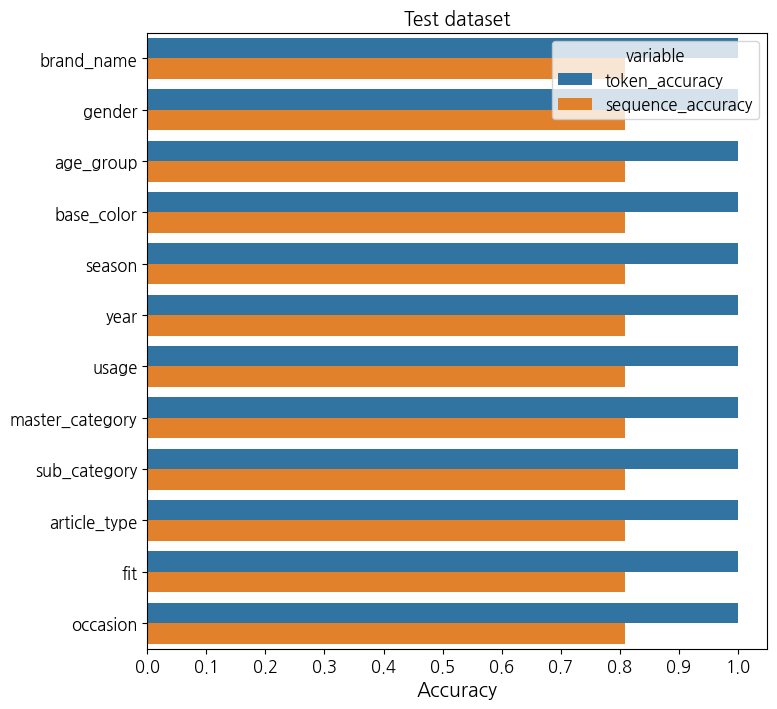

In [18]:
# 검증 지표 불러오기
df_metrics = pd.read_csv(model_dir.joinpath("metrics_test.csv"))

# 데이터 wide-to-long 변환
# `melt()`: "token_accuracy", "sequence_accuracy" 컬럼을 세로축으로 변환
# 결과: (target, variable, value)
df_metrics = df_metrics.melt(id_vars="target")
plt.figure(figsize=(8, 8), dpi=100)
sns.barplot(data=df_metrics, x="value", y="target", hue="variable")
plt.title("Test dataset", fontsize=14)
plt.xlabel("Accuracy", fontsize=14)
plt.ylabel("", fontsize=14)
plt.xticks(np.linspace(0, 1, 11))
plt.yticks(fontsize=12)
plt.show()

## Model Registry

In [19]:
bento_model = register_artifact_model(
    model_dir=model_dir,
    name="transformer",
    api_version="v1",
    metadata={"domain": "fashion", "description": "Transformer model artifact"},
)

# Sequence Vectors
- sequence vector 미리 추출하는 이유?
    - 학습 시퀀스를 벡터로 변환해두면, 이후 추천·검색·Projection 학습에 빠르게 활용 가능

In [20]:
# 1) 저장된 모델 설정(config) 불러오기
# - 학습 시 JSON으로 저장해둔 모델 설정값 로드
# - (feature_dims, output_dims, embedding_dim, seq_len 등 포함)
f = open(model_dir.joinpath("checkpoint/model_config.json"))
model_config = json.load(f)

# 2) 동일한 구조의 모델 생성
# - 학습 시 사용했던 config로 SimpleTransformer 초기화
model = SimpleTransformer(**model_config)

# 3) 학습된 파라미터(가중치) 불러오기
# - checkpoint/model.pt 파일에 저장된 state_dict 로드
# - `map_location`: 현재 사용 중인 device(CPU/GPU)에 맞게 매핑
# - `weights_only=True`: state_dict 외 불필요한 정보는 무시
model.load_state_dict(
    torch.load(
        f=model_dir.joinpath("checkpoint/model.pt"),
        map_location=torch.device(device),
        weights_only=True,
    )
)
model = model.to(device)

In [21]:
# 1) 추론용 데이터프레임 준비
# - feature 시퀀스 + mask + 타겟(`y_item_id`)만 남김
df_tmp = df_seq_encoded[feature_names + ["mask", "y_item_id"]]

# 2) Dataset & DataLoader 생성
dataset = SequentialDataset(
    df=df_tmp,
    feature_sequences=feature_names + ["mask"],
    action_sequence="action",
    device=device,
)
dataloader = DataLoader(dataset, batch_size=512, shuffle=False, pin_memory=False)

# 3) 시퀀스 벡터 추출
seq_vectors = []
model.eval().to(device)
with torch.no_grad():  # 추론 단계에서는 gradient 불필요
    for feature_sequences, action_sequence, masks in tqdm(
        dataloader, total=len(dataloader)
    ):
        # `model()`의 첫 번째 출력: sequence vector
        outputs = model(
            feature_sequences=feature_sequences,
            action_sequence=action_sequence,
            masks=masks,
        )[0]

        # GPU tensor -> numpy 변환
        outputs = outputs.detach().cpu().numpy()

        # 각 벡터를 L2 정규화 (cosine similarity 유사도 계산을 위함)
        seq_vectors.extend([value / np.linalg.norm(value) for value in outputs])

# 4) 결과 DataFrame
# - 원래 feature + 타겟(`y_item_id`) 유지
df_seq_vectors = df_seq_encoded[feature_names + ["y_item_id"]].copy()

# 시퀀스별 vector 추가
df_seq_vectors["seq_vector"] = seq_vectors

  0%|          | 0/408 [00:00<?, ?it/s]

/var/folders/9r/nl1h4s_n0wx65wzr5cmq1hy80000gn/T/ipykernel_8186/1059669762.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


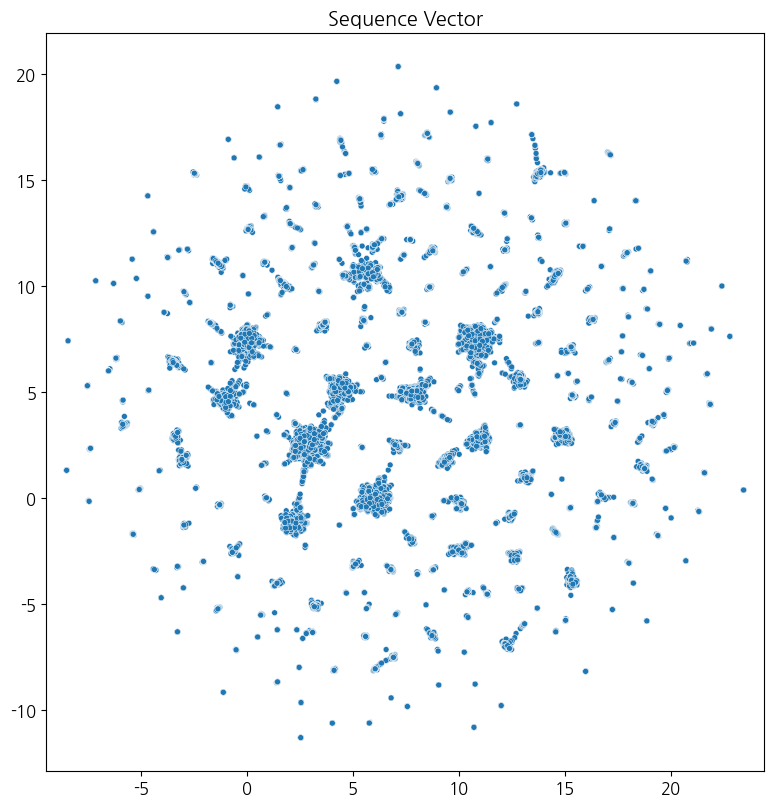

In [22]:
# 최종 sequence vector를 numpy 배열로 변환 (샘플로 20%만 추출)
seq_vectors = np.array(df_seq_vectors.sample(frac=0.2)["seq_vector"].tolist())

# UMAP 기반 차원 축소
# - metric="cosine": 임베딩 간 코사인 거리 기준으로 구조를 보존
reducer = umap.UMAP(metric="cosine")

# 시퀀스 벡터를 2차원 공간으로 임베딩
# - 유사한 시퀀스는 2D 공간에서 서로 가까이 위치
# - 특정 영역에 몰려 있는 점들은 같은 feature 조합일 가능성이 높음
embeddings = reducer.fit_transform(seq_vectors)

plt.figure(figsize=(8, 8))
sns.scatterplot(
    x=embeddings[:, 0], y=embeddings[:, 1], size=0.3, palette="bright", legend=False
)
plt.gca().set_aspect("equal", "datalim")
plt.tight_layout()
plt.title("Sequence Vector")
plt.show()

# Projection Model
- Sequence Vector -> Item Vector

In [23]:
seq_vectors = np.array(df_seq_vectors["seq_vector"].tolist())

In [24]:
# 모델 저장 경로 생성 (전처리 및 학습 관련 결과물)
model_dir = Path(root_dir).joinpath("data/outputs/fashion/regressor")
model_dir.mkdir(parents=True, exist_ok=True)

# 체크포인트 디렉토리 생성
checkpoint = model_dir.joinpath("checkpoint")
checkpoint.mkdir(parents=True, exist_ok=True)

## Dataset

/var/folders/9r/nl1h4s_n0wx65wzr5cmq1hy80000gn/T/ipykernel_8186/878635608.py:52: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


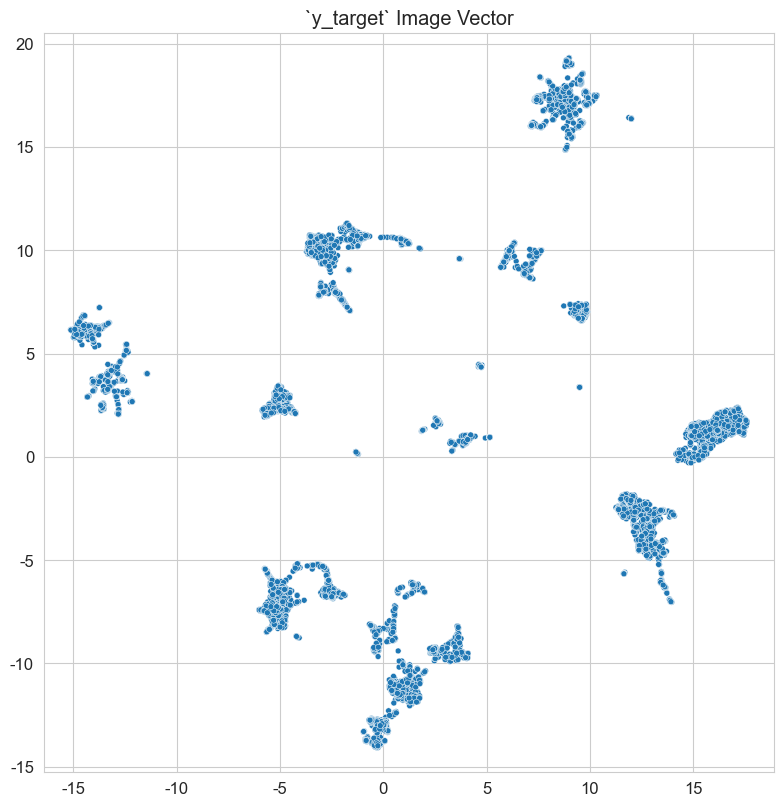

In [31]:
# 1) 이미지 기반 아이템 벡터 로드 (item_id, image_vector 매핑이 저장된 파일)
# - 사전 학습된 이미지 임베딩 벡터
image_vector_path = Path(root_dir).joinpath(
    "data/dataset/fashion/image_vectors.parquet"
)
df_image_vectors = pd.read_parquet(image_vector_path)

# {item_id: image_vector} 매핑 딕셔너리 생성
# - 예: {123: np.array([...]), 456: np.array([...]), ...}
item_vectors_map = dict(
    zip(df_image_vectors["item_id"], df_image_vectors["image_vector"].to_numpy())
)

# 2) 시퀀스 벡터 차원 정의
# `seq_vector_dim`: Transformer로부터 추출된 시퀀스 벡터 차원
seq_vector_dim = model_config["embedding_dim"]

# 3) 아이템 벡터 차원 정의
# `item_vector_dim`: 이미지 임베딩 벡터 차원
item_vector_dim = len(next(iter(item_vectors_map.values())))

# 4) 시퀀스 벡터별 target 상품 정의 (list 컬럼은 중복 제거가 안되므로, tuple로 변경 후 중복 제거)
df_seq_vectors_unique = df_seq_vectors[["seq_vector", "y_item_id"]].copy()
df_seq_vectors_unique["seq_vector"] = df_seq_vectors_unique["seq_vector"].apply(
    lambda x: x.tolist() if isinstance(x, np.ndarray) else x
)
df_seq_vectors_unique["seq_vector"] = df_seq_vectors_unique["seq_vector"].apply(
    lambda x: tuple(x) if isinstance(x, list) else x
)
df_seq_vectors_unique = df_seq_vectors_unique.drop_duplicates(ignore_index=True)
df_seq_vectors_unique["seq_vector"] = df_seq_vectors_unique["seq_vector"].apply(
    lambda x: list(x) if isinstance(x, tuple) else x
)

# 5) target 상품의 벡터 군집 조회 (참고용)
y_target_vectors = df_image_vectors[
    df_image_vectors["item_id"].isin(
        df_seq_vectors_unique["y_item_id"].unique().tolist()
    )
]["image_vector"].tolist()
y_target_vectors = np.array(y_target_vectors)

# UMAP 기반 차원 축소
# - metric="cosine": 임베딩 간 코사인 거리 기준으로 구조를 보존
reducer = umap.UMAP(metric="cosine")

# 시퀀스 벡터를 2차원 공간으로 임베딩
# - 유사한 시퀀스는 2D 공간에서 서로 가까이 위치
embeddings = reducer.fit_transform(y_target_vectors)

plt.figure(figsize=(8, 8))
sns.scatterplot(
    x=embeddings[:, 0], y=embeddings[:, 1], size=0.3, palette="bright", legend=False
)
plt.gca().set_aspect("equal", "datalim")
plt.tight_layout()
plt.title("`y_target` Image Vector")
plt.show()

In [26]:
# 1) item_id 매핑 준비
unique_item_ids = sorted(item_vectors_map.keys())
item_id_to_index = {item_id: idx for idx, item_id in enumerate(unique_item_ids)}
index_to_item_id = {idx: item_id for item_id, idx in item_id_to_index.items()}

# 2) 아이템 임베딩 테이블 생성
num_items = len(unique_item_ids)
item_vector_dim = len(next(iter(item_vectors_map.values())))
item_embedding_table = torch.zeros((num_items, item_vector_dim), dtype=torch.float32)
for item_id, vector in item_vectors_map.items():
    item_embedding_table[item_id_to_index[item_id]] = torch.tensor(
        vector, dtype=torch.float32
    )
item_embedding_table = item_embedding_table.to(device)

# 3) 학습 Dataset 생성
train_dataset = SequenceVectorDataset(
    item_id=df_seq_vectors_unique["y_item_id"].to_numpy().astype(np.int32),
    seq_vector=np.array(
        df_seq_vectors_unique["seq_vector"].to_list(), dtype=np.float32
    ),
    item_id_to_index=item_id_to_index,
    device=device,
)

# 4) DataLoader 정의
train_dataloader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,  # 학습 시 mini-batch 샘플링을 무작위로 하여 일반화 성능 향상
    pin_memory=False,  # DataLoader에서 메모리 고정 기능 (GPU transfer 최적화)
)

## Training

In [27]:
# 1) Projection MLP 초기화
reg_model = MultiOutputRegressor(
    input_dim=seq_vector_dim,  # 시퀀스 벡터 차원 (예: 64)
    output_dim=item_vector_dim,  # target 아이템 벡터 차원 (예: 이미지 임베딩 차원)
    hidden_dim=512,
    dropout=0.0,  # 기본 0.0 (BatchNorm 사용 중이라면 과도한 dropout 불필요할 수 있음)
)
reg_model.to(device)

# 모델 설정을 JSON 파일로 저장 (추후 재현/재학습 가능)
with open(checkpoint.joinpath("model_config.json"), "w") as f:
    json.dump(reg_model.config, f, ensure_ascii=False, indent=4)


# -----------------------------------------------
# 2) Loss / 옵티마이저 설정
# -----------------------------------------------
def cosine_contrastive_loss(
    outputs: torch.Tensor, targets: torch.Tensor, temperature: float = 0.2
):
    outputs = F.normalize(outputs, dim=-1)
    targets = F.normalize(targets, dim=-1)
    logits = torch.matmul(outputs, targets.T) / temperature
    labels = torch.arange(logits.size(0), device=logits.device)

    return F.cross_entropy(logits, labels)


optimizer = optim.AdamW(reg_model.parameters(), lr=0.001, weight_decay=0.0)

df_metrics = pd.DataFrame()
n_epochs = 100

# 3) 학습 루프
for epoch in range(n_epochs):
    reg_model.train()  # 학습 모드 전환 (dropout 등 활성화)

    losses = []  # epoch 평균 손실 계산용

    train_start_time = time.time()

    # (선택) 이번 epoch에 등장하는 고유 target 목록 (필요시 분석 용도)
    # target_item_ids = df_seq_vectors["y_item_id"].unique().tolist()

    # 3-1) 미니배치 학습
    for item_indices, seq_vectors in tqdm(
        train_dataloader, total=len(train_dataloader)
    ):
        # BatchNorm을 쓰는 모델에서 batch_size=1이면 통계 추정이 불안정하므로 임시로 2배 복제
        if item_indices.size(0) == 1:
            item_indices = item_indices.repeat(2, 1)
            seq_vectors = seq_vectors.repeat(2, 1)

        # Gradient 초기화
        optimizer.zero_grad()

        # 시퀀스 벡터를 아이템 벡터 공간으로 projection (예측값)
        outputs = reg_model(seq_vectors)

        # 3-2) item_id의 정답 벡터 조회
        target_item_vectors = item_embedding_table[item_indices].to(device)

        # 3-3) 손실 계산 & 역전파
        # - L2 정규화 후 코사인 손실 계산
        outputs = F.normalize(outputs, dim=-1)
        targets = F.normalize(target_item_vectors, dim=-1)
        loss = 1 - F.cosine_similarity(outputs, targets, dim=-1).mean()

        # InfoNCE Loss (Information Noise-Contrastive Estimation Loss)
        # temperature = 0.05
        # logits = torch.matmul(outputs, targets.T) / temperature
        # labels = torch.arange(logits.size(0), device=logits.device)
        # loss = F.cross_entropy(logits, labels)

        losses.append(loss.detach().cpu().numpy())

        loss.backward()
        optimizer.step()

    with torch.no_grad():
        cos_sim = F.cosine_similarity(outputs, targets, dim=-1).mean().item()
        print(f"Epoch {epoch + 1}/{n_epochs}: Loss={loss:.4f}, CosSim={cos_sim:.4f}")

    # -----------------------------------------------
    # 4) 체크포인트 저장
    # -----------------------------------------------
    torch.save(reg_model.state_dict(), checkpoint.joinpath("model.pt"))

    # -----------------------------------------------
    # 5) Epoch 결과 출력
    # -----------------------------------------------
    train_end_time = time.time()
    train_time = round(train_end_time - train_start_time, 2)
    print(f"Epoch {epoch + 1}/{n_epochs} - Elapsed time(sec): {train_time:.2f}")
    print(f"Loss: {np.mean(losses):.5f}")

    df_metrics = pd.concat(
        [df_metrics, pd.DataFrame({"epoch": [epoch + 1], "loss": [np.mean(losses)]})],
        ignore_index=True,
    )

# -----------------------------------------------
# 6) 학습 로그 저장
# -----------------------------------------------
df_metrics.to_csv(model_dir.joinpath("metrics_train.csv"), index=False)

  0%|          | 0/3253 [00:00<?, ?it/s]

Epoch 0: Loss=0.1469, CosSim=0.8531
Epoch 1/100 - Elapsed time(sec): 75.62
Loss: 0.17379


  0%|          | 0/3253 [00:00<?, ?it/s]

Epoch 1: Loss=0.1515, CosSim=0.8485
Epoch 2/100 - Elapsed time(sec): 72.02
Loss: 0.16405


  0%|          | 0/3253 [00:00<?, ?it/s]

...

Epoch 97: Loss=0.1283, CosSim=0.8717
Epoch 98/100 - Elapsed time(sec): 56.47
Loss: 0.12324


  0%|          | 0/3253 [00:00<?, ?it/s]

Epoch 98: Loss=0.1116, CosSim=0.8884
Epoch 99/100 - Elapsed time(sec): 60.52
Loss: 0.12305


  0%|          | 0/3253 [00:00<?, ?it/s]

Epoch 99: Loss=0.1418, CosSim=0.8582
Epoch 100/100 - Elapsed time(sec): 53.96
Loss: 0.12299


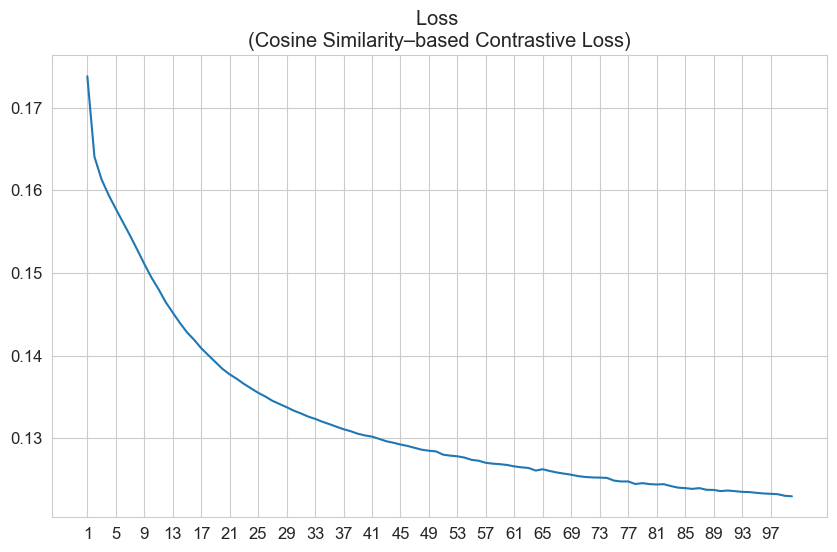

In [28]:
# 학습 로그 불러오기
df_metrics = pd.read_csv(model_dir.joinpath("metrics_train.csv"))

# 지표별 시각화
plt.figure(figsize=(10, 6), dpi=100)
sns.lineplot(x="epoch", y="loss", data=df_metrics)
plt.title("Loss \n(Cosine Similarity–based Contrastive Loss)")

# x, y축 이름은 생략
plt.xlabel("")
plt.ylabel("")

# epoch 눈금은 1단위로 표시
plt.xticks(np.arange(1, df_metrics["epoch"].max() + 1, 4))
plt.show()

## Model Registry

In [29]:
bento_model = register_artifact_model(
    model_dir=model_dir,
    name="regressor",
    api_version="v1",
    metadata={"domain": "fashion", "description": "Regressor model artifact"},
)

In [30]:
! bentoml models list

 Tag                     Module                  Size       Creation Time       
 regressor:4plltugdzwc…  custom.artifact_bundle  5.67 MiB   2025-11-18 00:55:50 
 lightgcn:4entaogdzoru…  custom.artifact_bundle  26.33 MiB  2025-11-18 00:41:27 
 transformer:i25t3lgdx…  custom.artifact_bundle  2.56 MiB   2025-11-17 22:56:55 
 regressor:w4u6dgv3gg5…  custom.artifact_bundle  5.67 MiB   2025-11-07 01:57:44 
 transformer:6zkykmv3e…  custom.artifact_bundle  2.56 MiB   2025-11-07 00:40:46 
 transformer:7bgyx3f3e…  custom.artifact_bundle  2.56 MiB   2025-11-06 23:57:52 
 lightgcn:a6ctu4fzas2r…  custom.artifact_bundle  26.33 MiB  2025-11-04 07:25:40 
 regressor:ltpmrzvyysf…  custom.artifact_bundle  5.67 MiB   2025-11-03 23:49:55 
 transformer:wyerh5fyw…  custom.artifact_bundle  2.56 MiB   2025-11-03 22:05:03 
 lightgcn:ici5bffqr6ru…  custom.artifact_bundle  26.33 MiB  2025-10-24 13:09:35 
 regressor:5idtbvfqrgv…  custom.artifact_bundle  5.67 MiB   2025-10-24 12:31:23 
 transformer:fmgu56vqp…  cus